In [ ]:
%pip install -qU langchain langchain-groq langchain-community langgraph langgraph-checkpoint-sqlite tavily-python langchain-tavily aiosqlite

In [1]:
#1. Librerías del Sistema y Tipado
import os
import sqlite3
from typing import Annotated, Any, Dict, List
from dataclasses import dataclass, field

# 2. Tipado extendido para el Estado de LangGraph
from typing_extensions import TypedDict

# 3. Componentes Core de LangChain y Mensajes
from langchain_core.messages import (
    AnyMessage, 
    SystemMessage, 
    HumanMessage, 
    ToolMessage, 
    AIMessage, 
    BaseMessage
)

# 4. Integración con el LLM de Groq (Corregido)
from langchain_groq import ChatGroq

# 5. Herramientas de Búsqueda (Tavily)
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch

# 6. Orquestación y Persistencia con LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\2493013089.py:24: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
import os
import sqlite3
from dotenv import load_dotenv
from langgraph.checkpoint.sqlite import SqliteSaver

# 1. Cargar las variables de entorno desde el archivo .env
load_dotenv()

# 2. Configurar las Claves de API para Groq y Tavily
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

# 3. Configurar la base de datos SQLite para la persistencia (Checkpointer)
conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

In [3]:
from uuid import uuid4

def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:
    # Creamos una copia de la lista de la izquierda (el estado actual)
    merged = left.copy()
    
    for message in right:
        # Para evitar el error de inmutabilidad, si el mensaje no tiene ID, 
        # le asignamos uno modificando su diccionario interno de forma segura
        if not message.id:
            message.id = str(uuid4())
            
        # Buscamos si el mensaje ya existe en nuestro estado por su ID
        for i, existing in enumerate(merged):
            if existing.id == message.id:
                # Si existe, lo reemplazamos (actualización)
                merged[i] = message
                break
        else:
            # Si el bucle 'for' termina sin romper (break), significa que es nuevo
            merged.append(message)
            
    return merged

# Definición del Estado del Agente utilizando tu reductor personalizado
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]

In [4]:
# 1. Inicializar la herramienta oficial de Tavily con tu límite de 2 resultados
tool = TavilySearchResults(max_results=2)

# 2. Agrupar las herramientas en una lista (clave para LangGraph)
tools = [tool]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\1356042029.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


In [5]:
# 1. Imports corregidos y ordenados (sin amontonamientos)
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, ToolMessage, AnyMessage
from typing import TypedDict, Annotated

class Agent:
    def __init__(self, model, tools, system="", checkpointer=None):
        self.system = system
        
        # Inicializar el grafo con el estado que definimos antes
        graph = StateGraph(AgentState)
        
        # Definición de Nodos (Cambiado a call_model)
        graph.add_node("llm", self.call_model)
        graph.add_node("action", self.take_action)
        
        # Bordes y caminos del flujo
        graph.add_conditional_edges("llm", self.exists_action, {True: "action", False: END})
        graph.add_edge("action", "llm")
        
        # Estructura moderna de LangGraph usando START
        graph.set_entry_point("llm")
        
        self.graph = graph.compile(
            checkpointer=checkpointer,
            interrupt_before=["action"]  # Interrupción humana/control antes de ejecutar la herramienta
        )
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def call_model(self, state: AgentState):
        messages = state['messages']
        
        # Corregido: Si hay un sistema de directivas y el historial está vacío (o no tiene SystemMessage), lo agregamos
        if self.system and not any(isinstance(m, SystemMessage) for m in messages):
            messages = [SystemMessage(content=self.system)] + messages
            
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        # Retorna True si el LLM decidió que necesita usar herramientas
        return len(result.tool_calls) > 0

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamando la herramienta: {t['name']} con los siguientes argumentos: {t['args']}")
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Retornando al modelo!")
        return {'messages': results}

In [6]:
from datetime import date
from langchain_groq import ChatGroq

# 1. Obtener la fecha actual con el formato correcto
current_date = date.today().strftime("%d/%m/%Y")

# 2. Definir el prompt del sistema optimizado (sin barras de escape innecesarias)
prompt = f"""Eres un asistente de investigación inteligente y altamente actualizado.
Tu prioridad principal es encontrar la información más RECIENTE y en TIEMPO REAL siempre que sea posible.
La fecha actual es {current_date}.
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", DEBES **incluir la fecha actual '{current_date}' en tu consulta a la herramienta de búsqueda**.
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}".
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy".
Utiliza el mecanismo de búsqueda para buscar información, siempre priorizando el "hoy" o el "ahora" cuando el contexto lo indique.
Tienes permiso para realizar múltiples llamadas (ya sea de forma conjunta o en secuencia).
Busca información solo cuando tengas claro lo que deseas.
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!"""

# 3. Inicializar el modelo con Groq (Corregido: Reemplazado Gemini)
# Usamos llama-3.3-70b-versatile que maneja de diez la lógica de agentes y tool calling
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

# 4. Instanciar tu Agente con la persistencia en SQLite
abot = Agent(model, [tool], system=prompt, checkpointer=memory)

In [7]:
import uuid

# Generar un identificador único global (UUID v4) para simular una nueva sesión de chat
dynamic_thread_id = str(uuid.uuid4())

print(f"Mi nuevo hilo dinámico es: {dynamic_thread_id}")

Mi nuevo hilo dinámico es: 47686470-251b-40a2-8ce9-d2c7409b24ff


In [8]:
# Generar el ID de sesión (asegurate de tener importado uuid)
session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando una nueva conversación con el ID: {session_id}\n")

user_message = "Cómo está el clima en Dallas Arlington Usa hoy?"
messages = [HumanMessage(content=user_message)]
thread_config = {"configurable": {"thread_id": session_id}}

print("--- Etapa 1: El agente procesa la entrada y decide la acción ---")
print(f"Usted: {user_message}")

# Primer stream: procesa hasta llegar a la interrupción (interrupt_before=["action"])
for event in abot.graph.stream({"messages": messages}, thread_config):
    for k, v in event.items():
        if k == "llm":
            last_message = v.get('messages', [])[-1]
            if isinstance(last_message, AIMessage) and last_message.tool_calls:
                print(f"\nAgente (decisión): {last_message.tool_calls}")
                print("\n--- AGENTE PAUSADO: Intervención humana requerida ---")
            else:
                print(f"\nAgente (respuesta directa/sin tool_calls): {last_message.content}")
                print("\n--- AGENTE PAUSADO (respuesta directa, sin acción pendiente) ---")

# --- Control del Estado Actual ---
current_state = abot.graph.get_state(thread_config)
last_state_message = current_state.values['messages'][-1]

# Corregido: Verificamos si "action" es el próximo nodo en el path de ejecución
if current_state and "action" in current_state.next and isinstance(last_state_message, AIMessage) and last_state_message.tool_calls:
    tool_calls_pending = last_state_message.tool_calls
    if tool_calls_pending:
        print("\nEl agente decidió ejecutar la(s) siguiente(s) acción(es) de herramienta:")
        for tc in tool_calls_pending:
            print(f"- Herramienta: {tc['name']}, Argumentos: {tc['args']}")

        # Intervención por consola de Windows
        user_input = input("\nDesea que el agente ejecute la(s) acción(es)? (sí/no): ").strip().lower()

        if user_input == 'sí' or user_input == 'si':
            print("\n--- Etapa 2: Retomando la ejecución (Agente ejecutará la acción) ---")
            
            # Al pasar None, LangGraph retoma EXACTAMENTE desde donde se quedó colgado (la acción)
            for event in abot.graph.stream(None, thread_config):
                for k, v in event.items():
                    if k == "action":
                        print(f"DEBUG: Herramienta ejecutada y resultado retornado.")
                    elif k == "llm":
                        final_response_message = v.get('messages', [])[-1].content
                        print(f"\nAgente (respuesta final): {final_response_message}")
            print("\n--- FIN DE LA INTERACCIÓN ---")
        else:
            print("\nEjecución de la acción cancelada por el usuario.")
            print("--- FIN DE LA INTERACCIÓN ---")
    else:
        print("\nEl agente no decidió ninguna acción de herramienta a pesar de la pausa. Interacción finalizada.")
else:
    print("\nEl agente respondió directamente o no pausó antes de una acción. No hay acciones pendientes de aprobación.")
    if current_state:
        final_response_message = current_state.values['messages'][-1].content
        print(f"Agente (respuesta directa): {final_response_message}")
    print("--- FIN DE LA INTERACCIÓN ---")

DEBUG: Iniciando una nueva conversación con el ID: df772718-9828-4ba9-91b5-2204ba761002

--- Etapa 1: El agente procesa la entrada y decide la acción ---
Usted: Cómo está el clima en Dallas Arlington Usa hoy?

Agente (decisión): [{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Dallas Arlington Usa 17/06/2026'}, 'id': 'x28mz483h', 'type': 'tool_call'}]

--- AGENTE PAUSADO: Intervención humana requerida ---

El agente decidió ejecutar la(s) siguiente(s) acción(es) de herramienta:
- Herramienta: tavily_search_results_json, Argumentos: {'query': 'clima en Dallas Arlington Usa 17/06/2026'}

--- Etapa 2: Retomando la ejecución (Agente ejecutará la acción) ---
Llamando la herramienta: tavily_search_results_json con los siguientes argumentos: {'query': 'clima en Dallas Arlington Usa 17/06/2026'}
Retornando al modelo!
DEBUG: Herramienta ejecutada y resultado retornado.

Agente (respuesta final): El clima en Dallas, Arlington, USA hoy (17/06/2026) es parcialmente nublado con u


--- Generando el flujo del Grafo del Agente ---


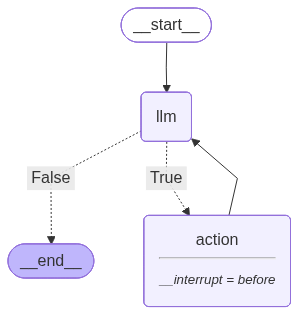

In [9]:
import requests
from IPython.display import Image, display

print("\n--- Generando el flujo del Grafo del Agente ---")

try:
    # 1. Intentar el método nativo (puede requerir dependencias locales)
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except Exception as e:
    print("No se pudo generar el PNG de forma local (es normal en Windows).")
    print("Tratando de renderizar vía API de Mermaid...")
    
    try:
        # 2. Si falla el local, extraemos el código de texto de Mermaid
        mermaid_code = abot.graph.get_graph().draw_mermaid()
        
        # Reemplazamos caracteres conflictivos para pasar el código por URL
        import urllib.parse
        encoded_code = urllib.parse.quote(mermaid_code)
        
        # Usamos el servicio gratuito oficial de Mermaid para obtener el PNG directo
        mermaid_url = f"https://mermaid.ink/png/{encoded_code}"
        
        print("\n--- Grafo Renderizado con Éxito ---")
        display(Image(url=mermaid_url))
        
    except Exception as e_mermaid:
        print(f"Error al generar o renderizar el código Mermaid: {e_mermaid}")
        
        # 3. Fallback final: te imprime el texto por si querés pegarlo a mano
        print("\n--- Código Mermaid Puro (Copia y pega en https://mermaid.live/) ---")
        try:
            print(abot.graph.get_graph().draw_mermaid())
        except:
            pass

In [10]:
import uuid
from IPython.display import Image, display
from langchain_core.messages import AIMessage, HumanMessage

# 1. Inicialización de la sesión limpia
new_session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando una nueva conversación con ID: {new_session_id}\n")

new_user_message = "Cuál es la distancia entre Kansas Usa y Dallas Usa?"
new_messages = [HumanMessage(content=new_user_message)]
new_thread_config = {"configurable": {"thread_id": new_session_id}}

print("--- Iniciando Nueva Interacción: Agente procesa la entrada y recibe la acción ---")
print(f"Usted: {new_user_message}")
print(f"DEBUG: ID del nuevo hilo: {new_session_id}")
print("\n--- Agente pensando y pausando ---")

# 2. Stream de la Etapa 1 con captura de excepciones
try:
    for event in abot.graph.stream({"messages": new_messages}, new_thread_config):
        for k, v in event.items():
            if k == "llm":
                if v and 'messages' in v and v['messages']:
                    llm_message_from_event = v['messages'][-1]  # Usamos el último para evitar despasajes
                    if hasattr(llm_message_from_event, 'tool_calls') and llm_message_from_event.tool_calls:
                        print(f"\nAgente (decisión): {llm_message_from_event.tool_calls}")
                        print("\n--- AGENTE PAUSADO: Intervención humana necesaria ---")
                    elif llm_message_from_event.content:
                        print(f"\nAgente (respuesta directa): {llm_message_from_event.content}")
                        print("\n--- AGENTE NO PAUSÓ POR LA HERRAMIENTA (Respuesta directa de la LLM) ---")
except Exception as e:
    print(f"DEBUG: Stream interrumpido como esperado: {e}")

# 3. Inspección profunda del Snapshot del Estado en SQLite
current_state_snapshot = abot.graph.get_state(new_thread_config)

if current_state_snapshot:
    print(f"\nDEBUG: Estado actual obtenido para el nuevo ID del hilo: {new_session_id}")
    
    snapshot_thread_id = None
    snapshot_thread_ts = None

    # Extracción segura de la configuración del checkpoint usando la estructura oficial
    if hasattr(current_state_snapshot, 'config') and isinstance(current_state_snapshot.config, dict):
        configurable = current_state_snapshot.config.get('configurable', {})
        if isinstance(configurable, dict):
            snapshot_thread_id = configurable.get('thread_id')
            # Corregido: LangGraph moderno guarda el identificador único temporal como 'checkpoint_id'
            snapshot_thread_ts = configurable.get('checkpoint_id') or configurable.get('thread_ts')
    
    if snapshot_thread_id is None:
        snapshot_thread_id = new_session_id

    print(f"DEBUG: ID del Hilo (del snapshot): {snapshot_thread_id}")
    print(f"DEBUG: Timestamp/ID del checkpoint (checkpoint_id): {snapshot_thread_ts}") 
    print(f"DEBUG: Cantidad de mensajes en el historial: {len(current_state_snapshot.values.get('messages', []))}")
    
    # Validación del último mensaje y estado de interrupción
    if current_state_snapshot.values and 'messages' in current_state_snapshot.values:
        last_msg_in_snapshot = current_state_snapshot.values['messages'][-1]
        print(f"DEBUG: Tipo del último mensaje en el snapshot: {type(last_msg_in_snapshot)}")
        
        if hasattr(last_msg_in_snapshot, 'tool_calls') and last_msg_in_snapshot.tool_calls:
            print(f"DEBUG: Último mensaje en el snapshot CONTIENE tool_calls. ¡LISTO PARA LA INYECCIÓN!")
        else:
            print(f"DEBUG: Último mensaje en el snapshot NO CONTIENE tool_calls. No requiere aprobación.")
            
    # Corregido: Si current_state_snapshot.next tiene elementos, significa que el grafo está frenado en un nodo
    if current_state_snapshot.next:
        print(f"\n--- Agente PAUSADO en el nodo: {current_state_snapshot.next}. Listo para la intervención. ---")
    else:
        print("\n--- ATENCIÓN: El agente NO está pausado. El grafo llegó al final (END). ---")
else:
    print(f"DEBUG: Ningún estado encontrado para el nuevo ID de hilo: {new_session_id}. Verifique la persistencia de SQLite.")

DEBUG: Iniciando una nueva conversación con ID: 847e6c45-38fb-4f4e-944b-abebe7026410

--- Iniciando Nueva Interacción: Agente procesa la entrada y recibe la acción ---
Usted: Cuál es la distancia entre Kansas Usa y Dallas Usa?
DEBUG: ID del nuevo hilo: 847e6c45-38fb-4f4e-944b-abebe7026410

--- Agente pensando y pausando ---

Agente (decisión): [{'name': 'tavily_search_results_json', 'args': {'query': 'distancia entre Kansas USA y Dallas USA'}, 'id': 'qrg64dgs8', 'type': 'tool_call'}]

--- AGENTE PAUSADO: Intervención humana necesaria ---

DEBUG: Estado actual obtenido para el nuevo ID del hilo: 847e6c45-38fb-4f4e-944b-abebe7026410
DEBUG: ID del Hilo (del snapshot): 847e6c45-38fb-4f4e-944b-abebe7026410
DEBUG: Timestamp/ID del checkpoint (checkpoint_id): 1f16a95b-92f9-67b5-8001-d2f5bd74a4c1
DEBUG: Cantidad de mensajes en el historial: 2
DEBUG: Tipo del último mensaje en el snapshot: <class 'langchain_core.messages.ai.AIMessage'>
DEBUG: Último mensaje en el snapshot CONTIENE tool_calls. ¡

In [ ]:
from langchain_core.messages import AIMessage

if current_state_snapshot:
    print("\n--- Iniciando MODIFICACIÓN MANUAL del Estado ---")
    
    # 1. Creamos el nuevo mensaje que queremos inyectar/pisar
    final_injected_message = AIMessage(
        content="La distancia entre Kansas Usa y Dallas Usa es de aproximadamente 450 km. (¡Datos introducidos manualmente por Usted!)"
    )
    
    # 2. Le asignamos el ID del último mensaje del snapshot para que LangGraph entienda 
    # que queremos REEMPLAZAR ese mensaje específico (la llamada a la herramienta), en vez de duplicarlo.
    last_msg = current_state_snapshot.values['messages'][-1]
    final_injected_message.id = last_msg.id

    # 3. LA SOLUCIÓN DEFINITIVA: Guardar el cambio de verdad en SQLite
    # Le pasamos los valores nuevos y la configuración del hilo que capturamos antes (new_thread_config)
    abot.graph.update_state(
        new_thread_config,
        {"messages": [final_injected_message]}
    )
    
    # 4. Verificación de control: Traemos un nuevo snapshot para comprobar que se guardó en la DB
    updated_snapshot = abot.graph.get_state(new_thread_config)
    last_saved_msg = updated_snapshot.values['messages'][-1]
    
    print("✔ ¡Estado modificado y guardado con éxito en checkpoints.db!")
    print(f"DEBUG: Contenido inyectado: {last_saved_msg.content}")
    print(f"DEBUG: Tipos de los últimos 2 mensajes en DB: {[m.type for m in updated_snapshot.values['messages'][-2:]]}")
    print(f"DEBUG: Próximo nodo pendiente en el grafo: {updated_snapshot.next} (Debería ser vacío '()' porque pisamos la acción)")

else:
    print("DEBUG: No es posible modificar el estado porque ningún snapshot del estado fue encontrado.")


--- Iniciando MODIFICACIÓN MANUAL del Estado ---
✔ ¡Estado modificado y guardado con éxito en checkpoints.db!
DEBUG: Contenido inyectado: La distancia entre Kansas Usa y Dallas Usa es de aproximadamente 11,300 km. (¡Datos introducidos manualmente por sted!)
DEBUG: Tipos de los últimos 2 mensajes en DB: ['human', 'ai']
DEBUG: Próximo nodo pendiente en el grafo: () (Debería ser vacío '()' porque pisamos la acción)


In [ ]:
print("\n--- Verificando el estado final tras la intervención ---")

# 1. Obtenemos el snapshot actualizado directamente de SQLite
final_state_snapshot = abot.graph.get_state(new_thread_config)

print("\n--- Salida final del agente en la base de datos ---")

# En LangGraph moderno, el estado siempre expone .values como un diccionario
if final_state_snapshot and final_state_snapshot.values:
    final_messages = final_state_snapshot.values.get('messages', [])
    
    if final_messages:
        last_message = final_messages[-1]
        
        # Verificamos si el último mensaje guardado es efectivamente nuestro AIMessage inyectado
        if isinstance(last_message, AIMessage):
            print(f"\nAgente (Respuesta Inyectada): {last_message.content}")
        else:
            print(f"\nAgente: El último mensaje no es un AIMessage. Tipo encontrado: {type(last_message)}")
    else:
        print("\nAgente: La lista de mensajes está vacía.")
else:
    print(f"DEBUG: No fue posible extraer el estado del hilo: {new_session_id}")

print("\n--- Flujo de Human-in-the-Loop concluído con éxito ---")